# Temporal and Behavioral Patterns of Toxicity and Sentiment in Twitter - Part 1: EDA

In this notebook we will perform data cleaning and analysis of 2 datasets. As a result, we get ready-to use datasets

## Imports

In [1]:
!pip install pyspark findspark -q

In [2]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum
import pyspark.sql.functions as F

# local, all kernels
spark = SparkSession.builder \
    .appName("TweetEDA") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/28 13:40:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql.functions import length, size, split
from pyspark.sql.functions import to_timestamp, dayofweek, hour, when, col, regexp_replace
from pyspark.sql.functions import split, udf, when, col
from pyspark.sql.types import IntegerType

### Convert datasets

Right now they arein kaggle dataset formats. But we need them in Spark DF

In [4]:
SENTIMENT140_PATH = "/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv"

# no header - make ourselves
sentiment140_schema = "polarity INT, id STRING, date STRING, query STRING, user STRING, text STRING"

df_sent = spark.read.csv(SENTIMENT140_PATH, schema=sentiment140_schema, header=False)

print("Sentiment140 downloaded")
df_sent.printSchema()
print(f"Number of lines: {df_sent.count()}")
df_sent.show(5, truncate=False)

Sentiment140 downloaded
root
 |-- polarity: integer (nullable = true)
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- query: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)



Number of lines: 1600000
+--------+----------+----------------------------+--------+---------------+-------------------------------------------------------------------------------------------------------------------+
|polarity|id        |date                        |query   |user           |text                                                                                                               |
+--------+----------+----------------------------+--------+---------------+-------------------------------------------------------------------------------------------------------------------+
|0       |1467810369|Mon Apr 06 22:19:45 PDT 2009|NO_QUERY|_TheSpecialOne_|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D|
|0       |1467810672|Mon Apr 06 22:19:49 PDT 2009|NO_QUERY|scotthamilton  |is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!    |
|0       |14678

In [5]:
TOXIC_TWEETS_PATH = "/kaggle/input/datasets/umitka/twitter-toxic-tweets/twitter_toxic_tweets.csv"

df_toxic = spark.read.csv(TOXIC_TWEETS_PATH, header=True, inferSchema=True)

print("Toxic Tweets downloaded")
df_toxic.printSchema()
print(f"Number of rows: {df_toxic.count()}")
df_toxic.show(5, truncate=False)

Toxic Tweets downloaded
root
 |-- id: integer (nullable = true)
 |-- label: integer (nullable = true)
 |-- tweet: string (nullable = true)

Number of rows: 31962
+---+-----+--------------------------------------------------------------------------------------------------------------------------+
|id |label|tweet                                                                                                                     |
+---+-----+--------------------------------------------------------------------------------------------------------------------------+
|1  |0    | @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run                    |
|2  |0    |@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked|
|3  |0    |  bihday your majesty                                                                                                     |
|4  |0    |#model   i love u

## First Glance

Check target distribution, nulls, duplicates, other anomalies

In [6]:
# nulls
def count_nulls(df):
    return df.select([_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

print("=== nulls in Sentiment140 ===")
count_nulls(df_sent).show()

print("=== nulls in Toxic Tweets ===")
count_nulls(df_toxic).show()

=== nulls in Sentiment140 ===


+--------+---+----+-----+----+----+
|polarity| id|date|query|user|text|
+--------+---+----+-----+----+----+
|       0|  0|   0|    0|   0|   0|
+--------+---+----+-----+----+----+

=== nulls in Toxic Tweets ===
+---+-----+-----+
| id|label|tweet|
+---+-----+-----+
|  0|    0|    0|
+---+-----+-----+



In [7]:
# Sentiment140: target - polarity
print("distribution of polarity in Sentiment140:")
df_sent.groupBy("polarity").count().orderBy("polarity").show()


distribution of polarity in Sentiment140:


+--------+------+
|polarity| count|
+--------+------+
|       0|800000|
|       4|800000|
+--------+------+



In [8]:
# Toxic Tweets: distribution of toxicity label
print("toxicity distribution:")

df_toxic.groupBy("label").count().show()

toxicity distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1| 2242|
|    0|29720|
+-----+-----+



In [9]:
# duplocates in Sentiment140 by user, date, text
total_sent = df_sent.count()
unique_sent = df_sent.select("user", "date", "text").distinct().count()
print(f"Sentiment140: overall {total_sent}, unique combinations (user+date+text) {unique_sent}")
print(f"Duplicates: {total_sent - unique_sent}")

# duplicates in toxic-datset by text
total_toxic = df_toxic.count()
unique_toxic = df_toxic.select("tweet").distinct().count()
print(f"\nToxic Tweets: overall {total_toxic}, unique {unique_toxic}")
print(f"Duplicates: {total_toxic - unique_toxic}")

Sentiment140: overall 1600000, unique combinations (user+date+text) 1598127
Duplicates: 1873

Toxic Tweets: overall 31962, unique 29528
Duplicates: 2434


In [10]:
# ----- Sentiment140: ex of duplicates user + date + text -----
from pyspark.sql.functions import count as _count, col, collect_list

dup_sent = (
    df_sent.groupBy("user", "date", "text")
           .agg(_count("*").alias("cnt"))
           .filter(col("cnt") > 1)
)

print(f"Duplicates groups in Sentiment140: {dup_sent.count()}")
print("Example:")
dup_sent.orderBy(col("cnt").desc()).show(5, truncate=50)

first_group = dup_sent.select("user", "date", "text").first()
df_sent.filter(
    (col("user") == first_group["user"]) &
    (col("date") == first_group["date"]) &
    (col("text")  == first_group["text"])
).show(truncate=False)

Duplicates groups in Sentiment140: 1865
Example:


+----------+----------------------------+--------------------------------------------------+---+
|      user|                        date|                                              text|cnt|
+----------+----------------------------+--------------------------------------------------+---+
|   lina003|Sun May 31 17:50:18 PDT 2009|is drinking Barq's and getting ready to eat som...|  4|
|  brentonk|Sun Jun 07 04:55:23 PDT 2009|                     Non-montonic shower controls |  3|
| maricrisg|Sat May 30 19:47:03 PDT 2009|@Momsmostwanted are we allowed to win 2x or 3x?...|  3|
|guinnessdj|Sun May 10 09:54:29 PDT 2009|@dublinblondie my mother always warned me to wa...|  3|
|   Zando21|Tue Jun 16 14:59:05 PDT 2009|            I feel sick and gross....I need a hug |  3|
+----------+----------------------------+--------------------------------------------------+---+
only showing top 5 rows


+--------+----------+----------------------------+--------+------+--------------------------------------------------------------------------------------------------------+
|polarity|id        |date                        |query   |user  |text                                                                                                    |
+--------+----------+----------------------------+--------+------+--------------------------------------------------------------------------------------------------------+
|0       |1468586841|Tue Apr 07 02:34:25 PDT 2009|NO_QUERY|Micc_x|@bradiewebbstack sway sway tour in julyyyyy! exitedd muchh  follow me pleaseeee? i need more followerss |
|4       |1468586841|Tue Apr 07 02:34:25 PDT 2009|NO_QUERY|Micc_x|@bradiewebbstack sway sway tour in julyyyyy! exitedd muchh  follow me pleaseeee? i need more followerss |
+--------+----------+----------------------------+--------+------+--------------------------------------------------------------------------

In [11]:
# ----- Toxic Tweets: tweet duplicates -----
dup_toxic = (
    df_toxic.groupBy("tweet")
            .agg(_count("*").alias("cnt"))
            .filter(col("cnt") > 1)
)

print(f"\nDuplicates group in Toxic Tweets: {dup_toxic.count()}")
print("Examples:")
dup_toxic.orderBy(col("cnt").desc()).show(5, truncate=50)

first_group = dup_toxic.select("tweet").first()
df_toxic.filter(
    (col("tweet") == first_group["tweet"])
).show(truncate=False)


Duplicates group in Toxic Tweets: 696
Examples:
+--------------------------------------------------+---+
|                                             tweet|cnt|
+--------------------------------------------------+---+
|#model   i love u take with u all the time in u...|319|
|i finally found a way how to delete old tweets!...| 82|
|     aww yeah it's all good bing bong bing bong   | 75|
|  i'm so   and #grateful now that - #affirmations | 56|
|@user you might be a libtard if... #libtard  #s...| 40|
+--------------------------------------------------+---+
only showing top 5 rows
+-----+-----+------------------------------------------------------------------------------+
|id   |label|tweet                                                                         |
+-----+-----+------------------------------------------------------------------------------+
|117  |0    |100 amazing health benefits of cucumbers!    #healthy is  !!  #altwaystoheal! |
|8784 |0    |100 amazing health benefits o

### Results of first glance

1. There is 0 null values in data - good
2. There are some duplicates in both datasets:
   - in sentiment: 1873 of 1600000 = less than 1%. Also in that dataset duplicates can have different polarity labels
   - in toxicity: 2434 of 31962 = 7% of data. To first glance, labels of duplicates are the same
3. In sentiment dataset(before cleaning duplicates), distribution of polarity is 1:1. In toxicity dataset target distribution is 2242:29720, so 93% of data is non-toxic

## EDA

In this section we will visualize target distributions, text length, Preliminary time patterns etc

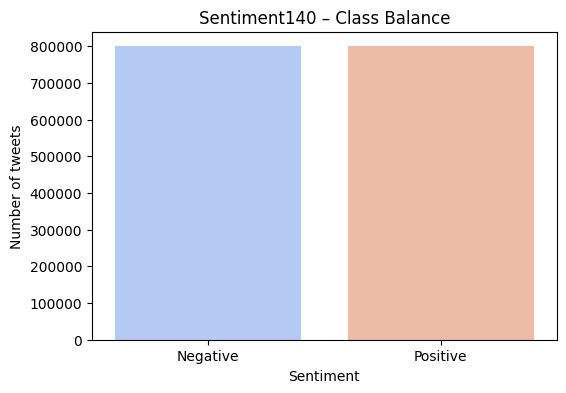

,polarity,count,label
0,0,800000,Negative
1,4,800000,Positive


In [12]:
polarity_dist = df_sent.groupBy("polarity").count().orderBy("polarity").toPandas()
polarity_dist["label"] = polarity_dist["polarity"].map({0: "Negative", 4: "Positive"})

plt.figure(figsize=(6,4))
sns.barplot(data=polarity_dist, x="label", y="count", hue="label", palette="coolwarm", legend=False)
plt.title("Sentiment140 – Class Balance")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.show()
polarity_dist

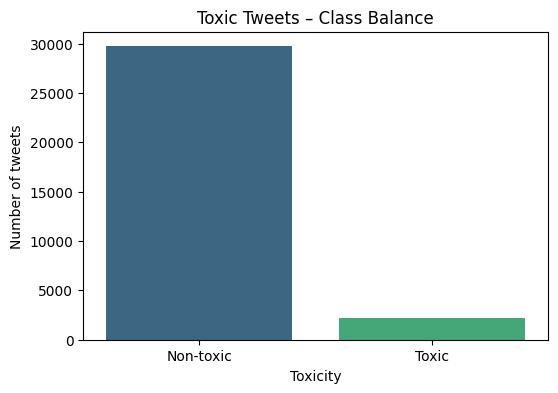

,label,count,label_str
0,0,29720,Non-toxic
1,1,2242,Toxic


In [13]:
tox_dist = df_toxic.groupBy("label").count().orderBy("label").toPandas()
tox_dist["label_str"] = tox_dist["label"].map({0: "Non-toxic", 1: "Toxic"})

plt.figure(figsize=(6,4))
sns.barplot(data=tox_dist, x="label_str", y="count", hue="label_str", palette="viridis", legend=False)
plt.title("Toxic Tweets – Class Balance")
plt.xlabel("Toxicity")
plt.ylabel("Number of tweets")
plt.show()
tox_dist

+-------+-----------------+-----------------+
|summary|          n_chars|          n_words|
+-------+-----------------+-----------------+
|  count|          1600000|          1600000|
|   mean|     74.041759375|     14.382130625|
| stddev|36.38799215515103|7.062139228418596|
|    min|                6|                2|
|    max|              359|              110|
+-------+-----------------+-----------------+



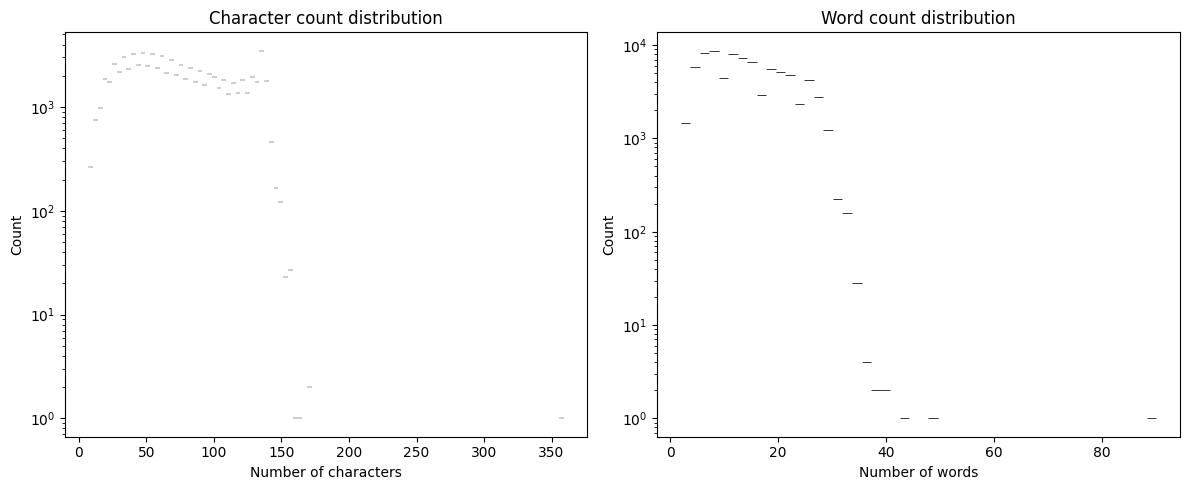

In [14]:
df_sent_len = df_sent.withColumn("n_chars", length(col("text"))) \
                     .withColumn("n_words", size(split(col("text"), " ")))

df_sent_len.select("n_chars", "n_words").describe().show()

sample_pd = df_sent_len.select("n_chars", "n_words").sample(False, 0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(sample_pd["n_chars"], bins=100, ax=axes[0], log_scale=(False, True))
axes[0].set_title("Character count distribution")
axes[0].set_xlabel("Number of characters")
sns.histplot(sample_pd["n_words"], bins=50, ax=axes[1], log_scale=(False, True))
axes[1].set_title("Word count distribution")
axes[1].set_xlabel("Number of words")
plt.tight_layout()
plt.show()



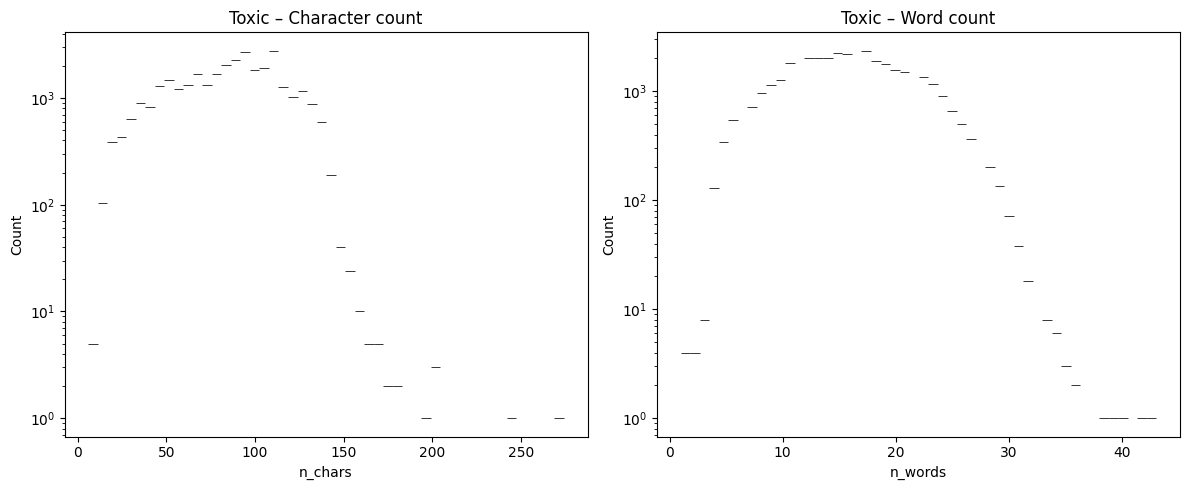

In [15]:
df_toxic_len = df_toxic.withColumn("n_chars", length(col("tweet"))) \
                       .withColumn("n_words", size(split(col("tweet"), " ")))
toxic_pd = df_toxic_len.select("n_chars", "n_words").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(toxic_pd["n_chars"], bins=50, ax=axes[0], log_scale=(False, True))
axes[0].set_title("Toxic – Character count")
sns.histplot(toxic_pd["n_words"], bins=50, ax=axes[1], log_scale=(False, True))
axes[1].set_title("Toxic – Word count")
plt.tight_layout()
plt.show()

### Preliminary Time Patterns (Sentiment140)

Let's check how the number of tweets and the share of positive messages depend on the day of the week and hour.  
*To do this, temporarily parse the date and add weekday/hour columns.*

In [16]:
# days to numbers
day_map = {"Mon":0, "Tue":1, "Wed":2, "Thu":3, "Fri":4, "Sat":5, "Sun":6}

day_to_int = udf(lambda d: day_map.get(d), IntegerType())

In [17]:
# data parse
df_sent_time_temp = df_sent \
    .withColumn("day_str", split(col("date"), " ").getItem(0)) \
    .withColumn("weekday", day_to_int(col("day_str"))) \
    .withColumn("time_str", split(col("date"), " ").getItem(3)) \
    .withColumn("hour", split(col("time_str"), ":").getItem(0).cast("int"))

null_weekday = df_sent_time_temp.filter(col("weekday").isNull()).count()
null_hour = df_sent_time_temp.filter(col("hour").isNull()).count()
print(f"Null weekday: {null_weekday}, Null hour: {null_hour}")


Null weekday: 0, Null hour: 0


In [18]:

df_sent_time_temp = df_sent_time_temp.withColumn(
    "sentiment_binary", when(col("polarity") == 4, 1).otherwise(0)
)

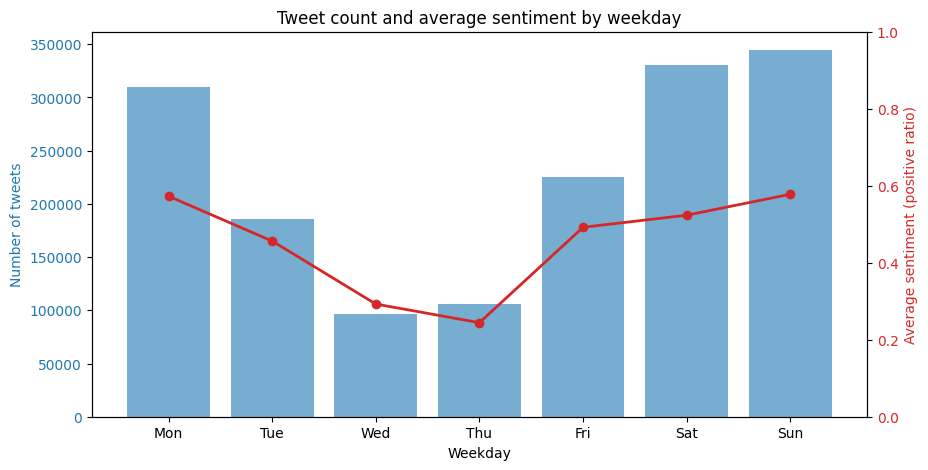

In [19]:
# days
weekday_counts = df_sent_time_temp.groupBy("weekday").count().orderBy("weekday").toPandas()
weekday_sentiment = df_sent_time_temp.groupBy("weekday").agg({"sentiment_binary": "mean"}) \
    .withColumnRenamed("avg(sentiment_binary)", "avg_sentiment") \
    .orderBy("weekday").toPandas()

day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
weekday_counts["day"] = weekday_counts["weekday"].map(day_names)
weekday_sentiment["day"] = weekday_sentiment["weekday"].map(day_names)

fig, ax1 = plt.subplots(figsize=(10,5))
color = 'tab:blue'
ax1.bar(weekday_counts["day"], weekday_counts["count"], color=color, alpha=0.6)
ax1.set_xlabel("Weekday")
ax1.set_ylabel("Number of tweets", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(weekday_sentiment["day"], weekday_sentiment["avg_sentiment"], color=color, marker='o', linewidth=2)
ax2.set_ylabel("Average sentiment (positive ratio)", color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1)
plt.title("Tweet count and average sentiment by weekday")
plt.show()

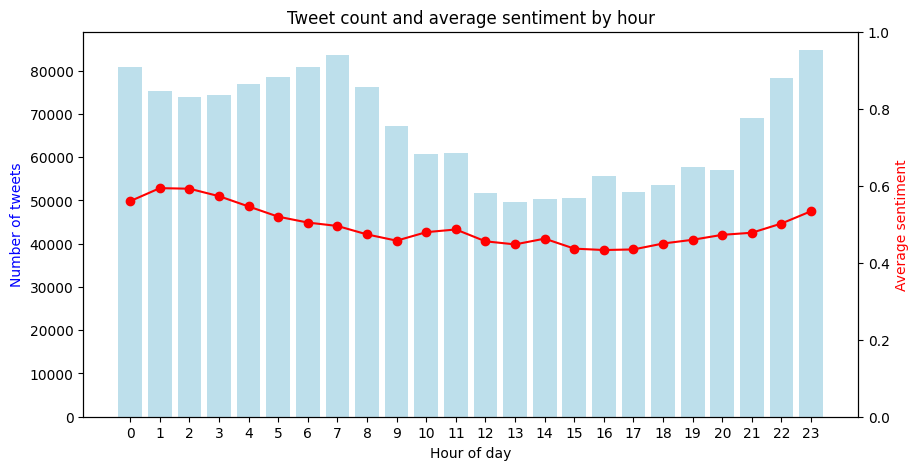

In [20]:
# by hour
hour_counts = df_sent_time_temp.groupBy("hour").count().orderBy("hour").toPandas()
hour_sentiment = df_sent_time_temp.groupBy("hour").agg({"sentiment_binary": "mean"}) \
                     .withColumnRenamed("avg(sentiment_binary)", "avg_sentiment") \
                     .orderBy("hour").toPandas()

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(hour_counts["hour"], hour_counts["count"], color='lightblue', alpha=0.8)
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Number of tweets", color='blue')
ax2 = ax1.twinx()
ax2.plot(hour_sentiment["hour"], hour_sentiment["avg_sentiment"], color='red', marker='o')
ax2.set_ylabel("Average sentiment", color='red')
ax2.set_ylim(0,1)
plt.title("Tweet count and average sentiment by hour")
plt.xticks(range(0,24))
plt.show()

### Key EDA Findings

- **No missing values** in either dataset.
- **Duplicates:**
  - Sentiment140: ~ 1,873 duplicate rows (<1%). The same tweet (user+date+text) can have different `polarity` (0 and 4) – when removing duplicates we need to decide which label to keep.
  - Toxic Tweets: ~ 2,434 duplicate rows (~ 7%). Most duplicates are repeating spam-like phrases.
- **Class balance:**
  - Sentiment140 is perfectly balanced (800k negative / 800k positive).
  - Toxic Tweets is heavily imbalanced (2,242 toxic / 29,720 non-toxic, ~7% toxic). This is important for training the classifier – we will use precision/recall metrics.
- **Text length:** Most tweets fit within the ~140-character limit (average ~74 characters, 14 words). There are outliers up to 359 characters – probably due to links or retweets.
- **Time patterns (Sentiment140):**  
  - The number of tweets and average positive sentiment depend on weekday and varies slightly with hour.  
  - This confirms that temporal factors may influence emotional tone and should be included in the toxicity analysis.

## Cleaning

 When removing duplicates, we keep the first occurrence of polarity for each key (user+date+cleaned_text). 
Conflicting polarity labels among duplicates are very rare, so this simplification has negligible impact.

 Steps:
1. Normalize text: lowercase, remove URLs, mentions, special characters.
2. Remove duplicate tweets.
3. Prepare final columns for next notebook.

In [21]:
import re
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def clean_tweet(text):
    if text is None:
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove special characters, keep letters, numbers and spaces
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean_text_udf = udf(clean_tweet, StringType())

In [22]:
# Sentiment140: apply cleaning to "text" column
df_sent_clean = df_sent.withColumn("cleaned_text", clean_text_udf(col("text")))

print("=== Sentiment140 before/after ===")
df_sent_clean.select("text", "cleaned_text").show(5, truncate=40)


=== Sentiment140 before/after ===
+----------------------------------------+----------------------------------------+
|                                    text|                            cleaned_text|
+----------------------------------------+----------------------------------------+
|@switchfoot http://twitpic.com/2y1zl ...|a thats a bummer you shoulda got davi...|
|is upset that he can't update his Fac...|is upset that he cant update his face...|
|@Kenichan I dived many times for the ...|i dived many times for the ball manag...|
|my whole body feels itchy and like it...|my whole body feels itchy and like it...|
|@nationwideclass no, it's not behavin...|no its not behaving at all im mad why...|
+----------------------------------------+----------------------------------------+
only showing top 5 rows


In [23]:
# Toxic Tweets: apply cleaning to "tweet" column
df_toxic_clean = df_toxic.withColumn("cleaned_text", clean_text_udf(col("tweet")))

print("=== Toxic Tweets before/after ===")
df_toxic_clean.select("tweet", "cleaned_text").show(5, truncate=40)

=== Toxic Tweets before/after ===
+----------------------------------------+----------------------------------------+
|                                   tweet|                            cleaned_text|
+----------------------------------------+----------------------------------------+
| @user when a father is dysfunctional...|when a father is dysfunctional and is...|
|@user @user thanks for #lyft credit i...|thanks for lyft credit i cant use cau...|
|                     bihday your majesty|                     bihday your majesty|
|#model   i love u take with u all the...|model i love u take with u all the ti...|
|  factsguide: society now    #motivation|       factsguide society now motivation|
+----------------------------------------+----------------------------------------+
only showing top 5 rows


In [24]:
# We keep the first frequent polarity per key (user, date, cleaned_text).
from pyspark.sql.functions import first, count

# Group by key and find the dominant polarity (max count, then min value as tiebreaker)
key_cols = ["user", "date", "cleaned_text"]
df_sent_dedup = df_sent_clean.groupBy(*key_cols) \
    .agg(
        count("*").alias("_dup_count"),
        first("polarity").alias("polarity")
    ) \
    .drop("_dup_count")

print(f"After deduplication Sentiment140: {df_sent_dedup.count()} rows (was {df_sent_clean.count()})")


After deduplication Sentiment140: 1598002 rows (was 1600000)


In [25]:
# ----- Toxic Tweets: drop duplicates based on cleaned_text -----
df_toxic_dedup = df_toxic_clean.dropDuplicates(["cleaned_text"])
print(f"After deduplication Toxic Tweets: {df_toxic_dedup.count()} rows (was {df_toxic_clean.count()})")

After deduplication Toxic Tweets: 28442 rows (was 31962)


In [26]:
# Re-use the parsing we had earlier, but now on df_sent_dedup
from pyspark.sql.functions import split, udf, when, col
from pyspark.sql.types import IntegerType

day_map = {"Mon":0, "Tue":1, "Wed":2, "Thu":3, "Fri":4, "Sat":5, "Sun":6}
day_to_int = udf(lambda d: day_map.get(d), IntegerType())

df_sent_final = df_sent_dedup \
    .withColumn("day_str", split(col("date"), " ").getItem(0)) \
    .withColumn("weekday", day_to_int(col("day_str"))) \
    .withColumn("time_str", split(col("date"), " ").getItem(3)) \
    .withColumn("hour", split(col("time_str"), ":").getItem(0).cast("int")) \
    .select("user", "cleaned_text", "polarity", "weekday", "hour")

# For toxic dataset, we just keep relevant columns
df_toxic_final = df_toxic_dedup.select("cleaned_text", "label")

In [27]:
# Check for empty texts
empty_sent = df_sent_final.filter(col("cleaned_text") == "").count()
empty_toxic = df_toxic_final.filter(col("cleaned_text") == "").count()
print(f"Empty texts - Sentiment140: {empty_sent}, Toxic: {empty_toxic}")

# Quick look at final schemas
df_sent_final.printSchema()
df_toxic_final.printSchema()
df_sent_final.show(3, truncate=50)
df_toxic_final.show(3, truncate=50)

Empty texts - Sentiment140: 3595, Toxic: 1
root
 |-- user: string (nullable = true)
 |-- cleaned_text: string (nullable = true)
 |-- polarity: integer (nullable = true)
 |-- weekday: integer (nullable = true)
 |-- hour: integer (nullable = true)

root
 |-- cleaned_text: string (nullable = true)
 |-- label: integer (nullable = true)



+-------------+--------------------------------------------------+--------+-------+----+
|         user|                                      cleaned_text|polarity|weekday|hour|
+-------------+--------------------------------------------------+--------+-------+----+
|scotthamilton|is upset that he cant update his facebook by te...|       0|      0|  22|
|      ElleCTF|    my whole body feels itchy and like its on fire|       0|      0|  22|
|   starkissed|ahh ive always wanted to see rent love the soun...|       0|      0|  22|
+-------------+--------------------------------------------------+--------+-------+----+
only showing top 3 rows


+--------------------------------------------------+-----+
|                                      cleaned_text|label|
+--------------------------------------------------+-----+
|                               bihday your majesty|    0|
|cnn calls michigan middle school build the wall...|    1|
|no comment in australia opkillingbay seashepher...|    1|
+--------------------------------------------------+-----+
only showing top 3 rows


In [28]:
df_sent_final = df_sent_final.filter(col("cleaned_text") != "")
df_toxic_final = df_toxic_final.filter(col("cleaned_text") != "")

## Save

In [29]:
df_sent_final.write.mode("overwrite").parquet("/kaggle/working/sentiment140_cleaned.parquet")
df_toxic_final.write.mode("overwrite").parquet("/kaggle/working/toxic_cleaned.parquet")